# TT-26 — CNN: Sàng lọc viêm phổi trên ảnh X-quang ngực

> ⚖️ **CẢNH BÁO Y TẾ:** đây là công cụ **sắp thứ tự ưu tiên đọc phim**, KHÔNG phải công cụ chẩn đoán.
> Dữ liệu từ Quảng Châu (Trung Quốc), bệnh nhi 1–5 tuổi — không tổng quát hoá cho người lớn hay dân số khác.
> Mọi ca đều phải có bác sĩ đọc lại.

In [13]:
import os, sys
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("Thư mục làm việc:", os.getcwd())

DATA_DIR = "data/chest_xray"   # sửa nếu dữ liệu của bạn nằm chỗ khác
os.makedirs("reports", exist_ok=True)
os.makedirs("models", exist_ok=True)
assert os.path.isdir(DATA_DIR), f"Không thấy {DATA_DIR} — kiểm tra lại đường dẫn"
assert os.path.isdir("src"), "Không thấy thư mục src/ — kiểm tra lại cấu trúc project"

Thư mục làm việc: d:\TT_ML\TT-26-CNN_Linh


## Bước 1: Đếm ảnh, phát hiện 3 vấn đề của dataset

In [14]:
from src.data_pipeline import print_dataset_report, build_datasets
print_dataset_report(DATA_DIR)

=== BÁO CÁO SỐ LƯỢNG ẢNH ===
train  (n= 5216): NORMAL: 1341 | PNEUMONIA: 3875
val    (n=   16): NORMAL: 8 | PNEUMONIA: 8
test   (n=  624): NORMAL: 234 | PNEUMONIA: 390

 Tập val gốc quá nhỏ (< 50 ảnh) -> KHÔNG dùng để chọn model.
 Mất cân bằng lớp trong train: PNEUMONIA chiếm 74.3%.
 Phân phối lệch: train PNEUMONIA=74.3% vs test PNEUMONIA=62.5%.


## Bước 2-4: Tự tách val 15%, class_weight, augmentation (không lật ngang)

In [15]:
train_ds, val_ds, test_ds, class_weight, class_names = build_datasets(DATA_DIR)
print(class_names, class_weight)

Found 5216 files belonging to 2 classes.
Using 4434 files for training.
Found 5216 files belonging to 2 classes.
Using 782 files for validation.
Found 624 files belonging to 2 classes.
['NORMAL', 'PNEUMONIA'] {np.int64(1): 0.675296984465428, np.int64(0): 1.9261511728931364}


## Bước 3: Xem 8 ảnh mỗi lớp

Found 5216 files belonging to 2 classes.


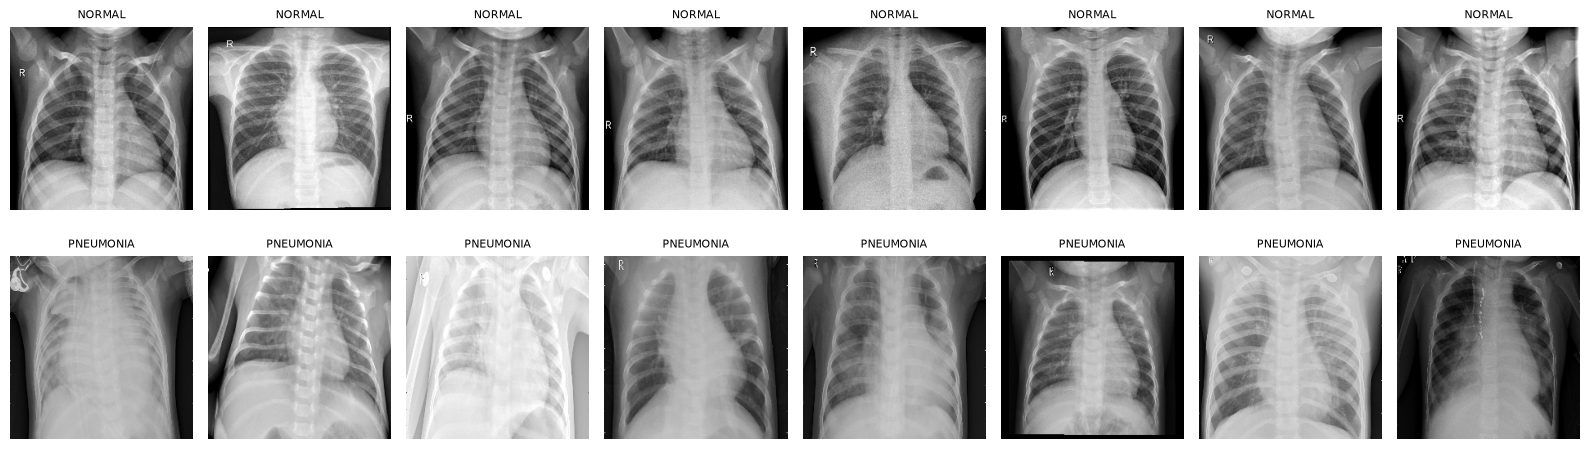

In [16]:
import matplotlib.pyplot as plt
import tensorflow as tf

raw_ds = tf.keras.utils.image_dataset_from_directory(
    f"{DATA_DIR}/train", image_size=(224, 224), batch_size=32, shuffle=True, seed=1)
names = raw_ds.class_names
shown = {c: 0 for c in names}
plt.figure(figsize=(16, 5))
for images, labels in raw_ds:
    for img, lab in zip(images, labels):
        cls = names[int(lab)]
        if shown[cls] < 8:
            plt.subplot(2, 8, shown[cls] + 1 + 8 * names.index(cls))
            plt.imshow(img.numpy().astype("uint8")); plt.title(cls, fontsize=8); plt.axis("off")
            shown[cls] += 1
    if all(v >= 8 for v in shown.values()):
        break
plt.tight_layout(); plt.show()

## Bước 5-10: Huấn luyện (baseline → transfer → fine-tune), chọn ngưỡng, đánh giá test

Trên CPU bước này chạy lâu (có thể vài giờ).

In [17]:
!python -m src.train --data_dir {DATA_DIR} --out_dir reports --models_dir models

OK
=== BÁO CÁO SỐ LƯỢNG ẢNH ===
train  (n= 5216): NORMAL: 1341 | PNEUMONIA: 3875
val    (n=   16): NORMAL: 8 | PNEUMONIA: 8
test   (n=  624): NORMAL: 234 | PNEUMONIA: 390

 Tập val gốc quá nhỏ (< 50 ảnh) -> KHÔNG dùng để chọn model.
 Mất cân bằng lớp trong train: PNEUMONIA chiếm 74.3%.
 Phân phối lệch: train PNEUMONIA=74.3% vs test PNEUMONIA=62.5%.
Found 5216 files belonging to 2 classes.
Using 4434 files for training.
Found 5216 files belonging to 2 classes.
Using 782 files for validation.
Found 624 files belonging to 2 classes.
class_names = ['NORMAL', 'PNEUMONIA'], class_weight = {np.int64(1): 0.675296984465428, np.int64(0): 1.9261511728931364}

### GIAI ĐOẠN 0: Baseline CNN train từ đầu ###
Epoch 1/15

  1/139 ━━━━━━━━━━━━━━━━━━━━ 8:07 4s/step - accuracy: 0.5938 - auc: 0.3333 - loss: 1.0716 - precision: 0.7083 - recall: 0.7391
  2/139 ━━━━━━━━━━━━━━━━━━━━ 2:49 1s/step - accuracy: 0.5469 - auc: 0.4112 - loss: 0.9233 - precision: 0.6977 - recall: 0.6522
  3/139 ━━━━━━━━━━━━━━━━━━━━ 2

I0000 00:00:1790578781.564803   19712 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790578783.090521   19712 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790578783.631150   19712 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
d:\TT_ML\Nappii\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was pass

## Bước 11: Grad-CAM 

In [18]:
!python -m src.gradcam --model models/best_model.keras --data_dir {DATA_DIR} --out_dir reports --n_images 6

Dùng base_name=efficientnetb0, last_conv_layer=top_conv
Found 624 files belonging to 2 classes.
Đã lưu Grad-CAM -> reports\gradcam_examples.png

 KIỂM TRA BẰNG MẮT: vùng nóng (đỏ/vàng) có nằm TRONG vùng phổi không?
   Nếu heatmap tập trung vào góc ảnh, chữ, hoặc viền phim -> model đang
   'gian lận' bằng manh mối giả, KHÔNG học đặc trưng y khoa thật -> phải
   ghi rõ điều này trong báo cáo và cân nhắc lại augmentation/crop ảnh.
OK


I0000 00:00:1790579957.842461   12640 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790579959.583454   12640 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790579961.005259   12640 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Bước 12: Phân tích 10 ca dự đoán sai

In [19]:
import json
with open("reports/final_results.json") as f:
    results = json.load(f)
threshold = results["threshold"]
print("Ngưỡng:", threshold, "| Số ca bỏ sót (FN):", results["test"]["fn"])
!python -m src.evaluate --model models/best_model.keras --data_dir {DATA_DIR} --threshold {threshold} --out_dir reports

Ngưỡng: 0.42000000000000004 | Số ca bỏ sót (FN): 0
Found 624 files belonging to 2 classes.
Đã lưu 10 ca dự đoán sai -> reports\ca_du_doan_sai.png
  Trong đó: 323 ca BỎ SÓT viêm phổi (false negative), 32 ca báo động giả (false positive)
\ Gợi ý phân tích nguyên nhân :
  - Ảnh mờ, chụp lệch tư thế, hoặc chất lượng thấp?
  - Vùng tổn thương quá nhỏ/mờ so với độ phân giải 224x224?
  - Nhãn gốc trong dataset có khả năng bị gán sai (label noise)?
  - Model có bị 'đánh lừa' bởi chi tiết không liên quan (đối chiếu với Grad-CAM)?


d:\TT_ML\TT-26-CNN_Linh\src\evaluate.py:70: SyntaxWarning: invalid escape sequence '\ '
  "\ Gợi ý phân tích nguyên nhân :\n"
I0000 00:00:1790579967.418121   17092 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790579969.147326   17092 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790579970.590754   17092 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate c

## Xem kết quả

learning_curves.png


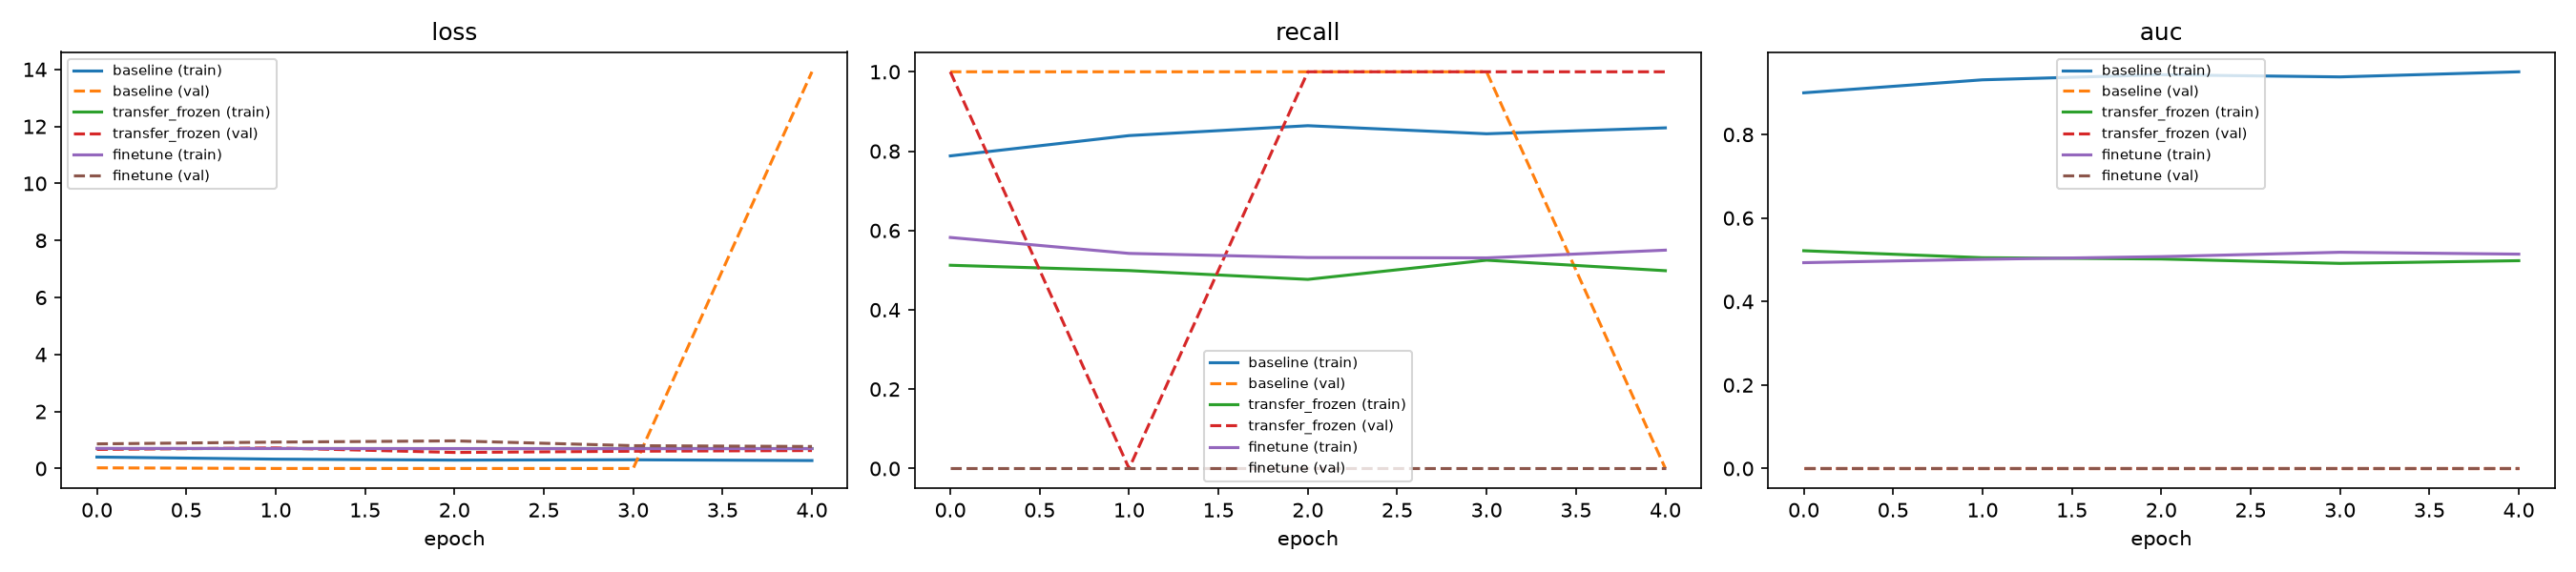

confusion_matrix_test.png


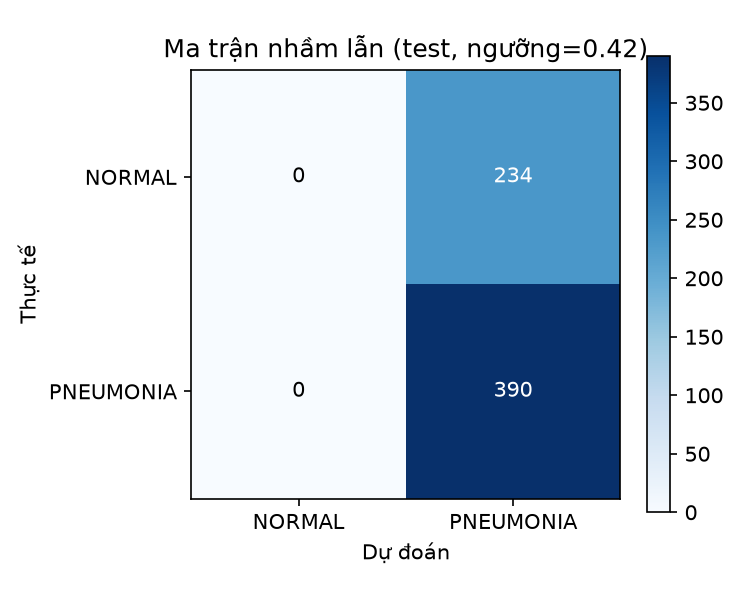

gradcam_examples.png


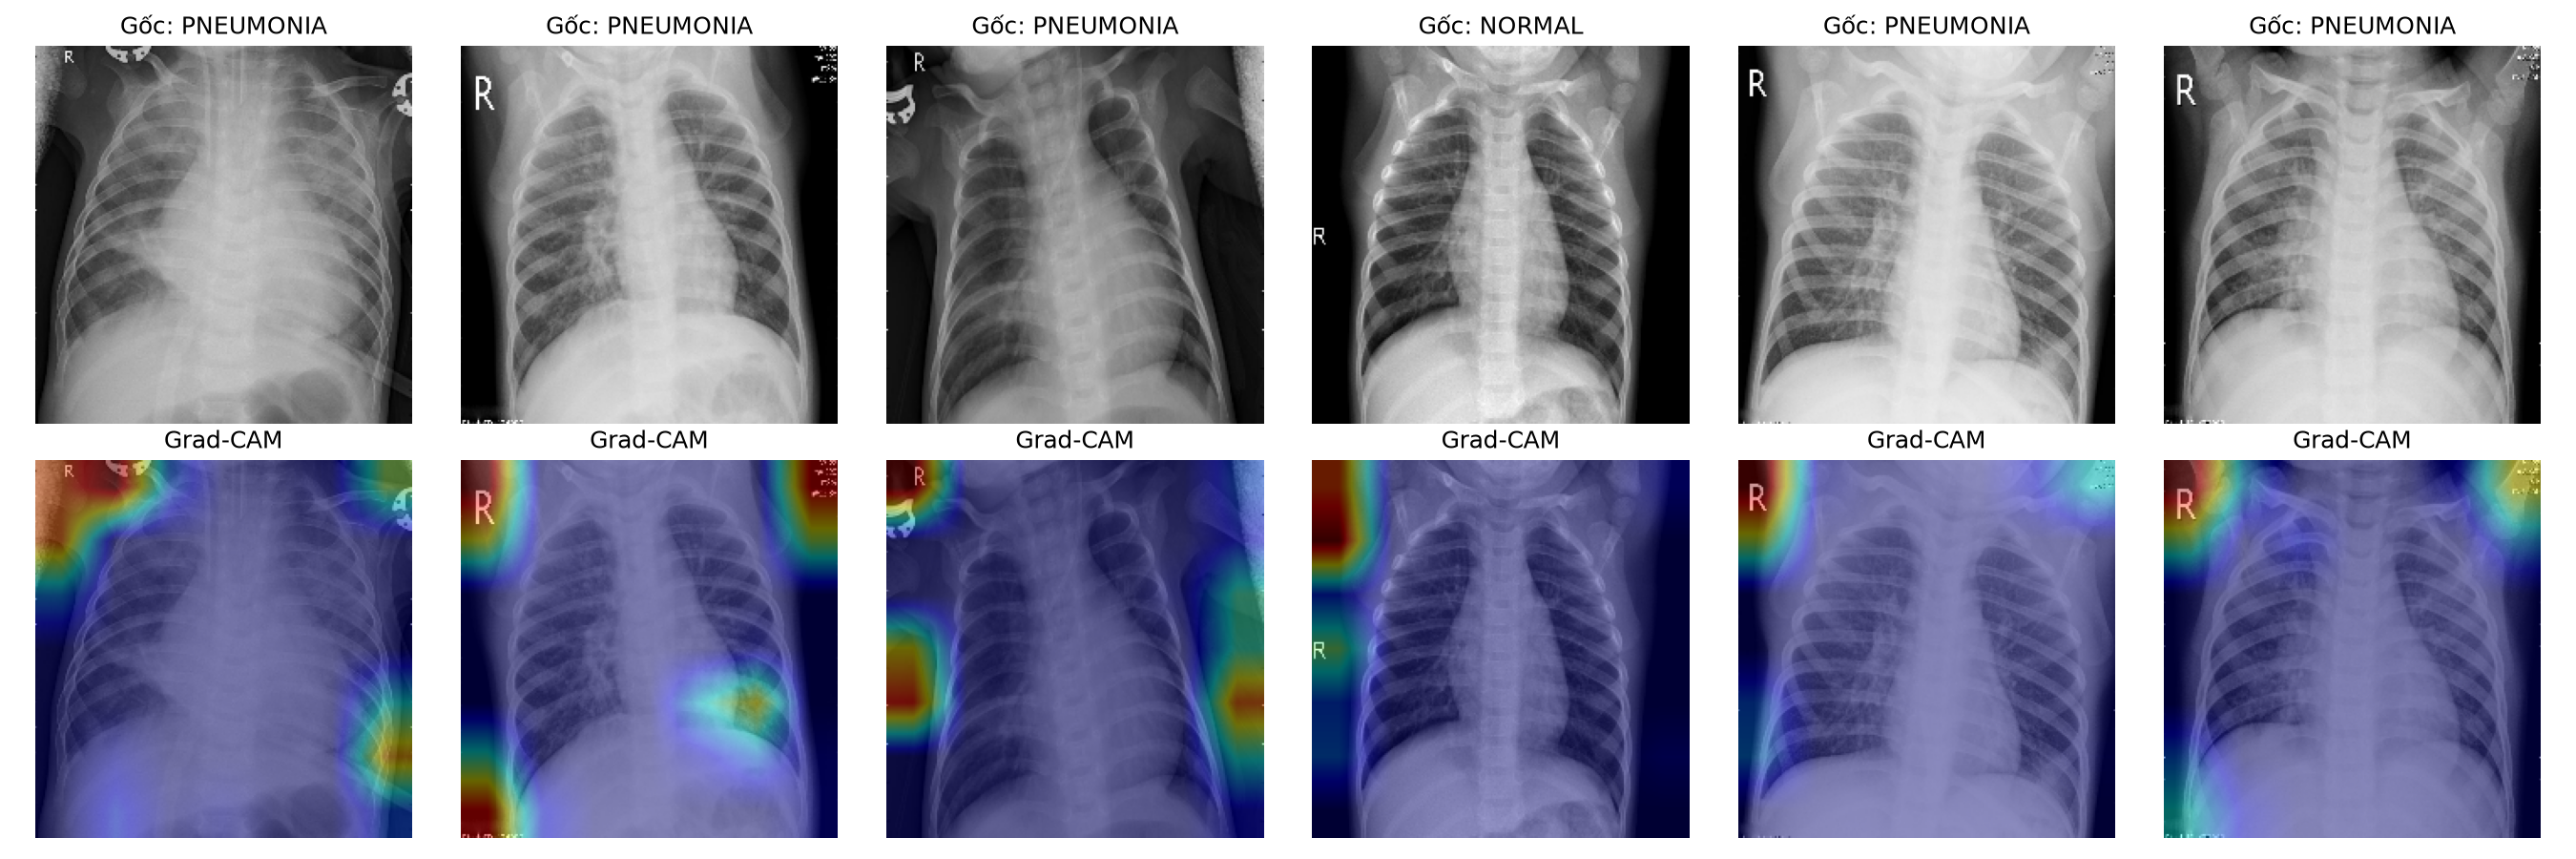

ca_du_doan_sai.png


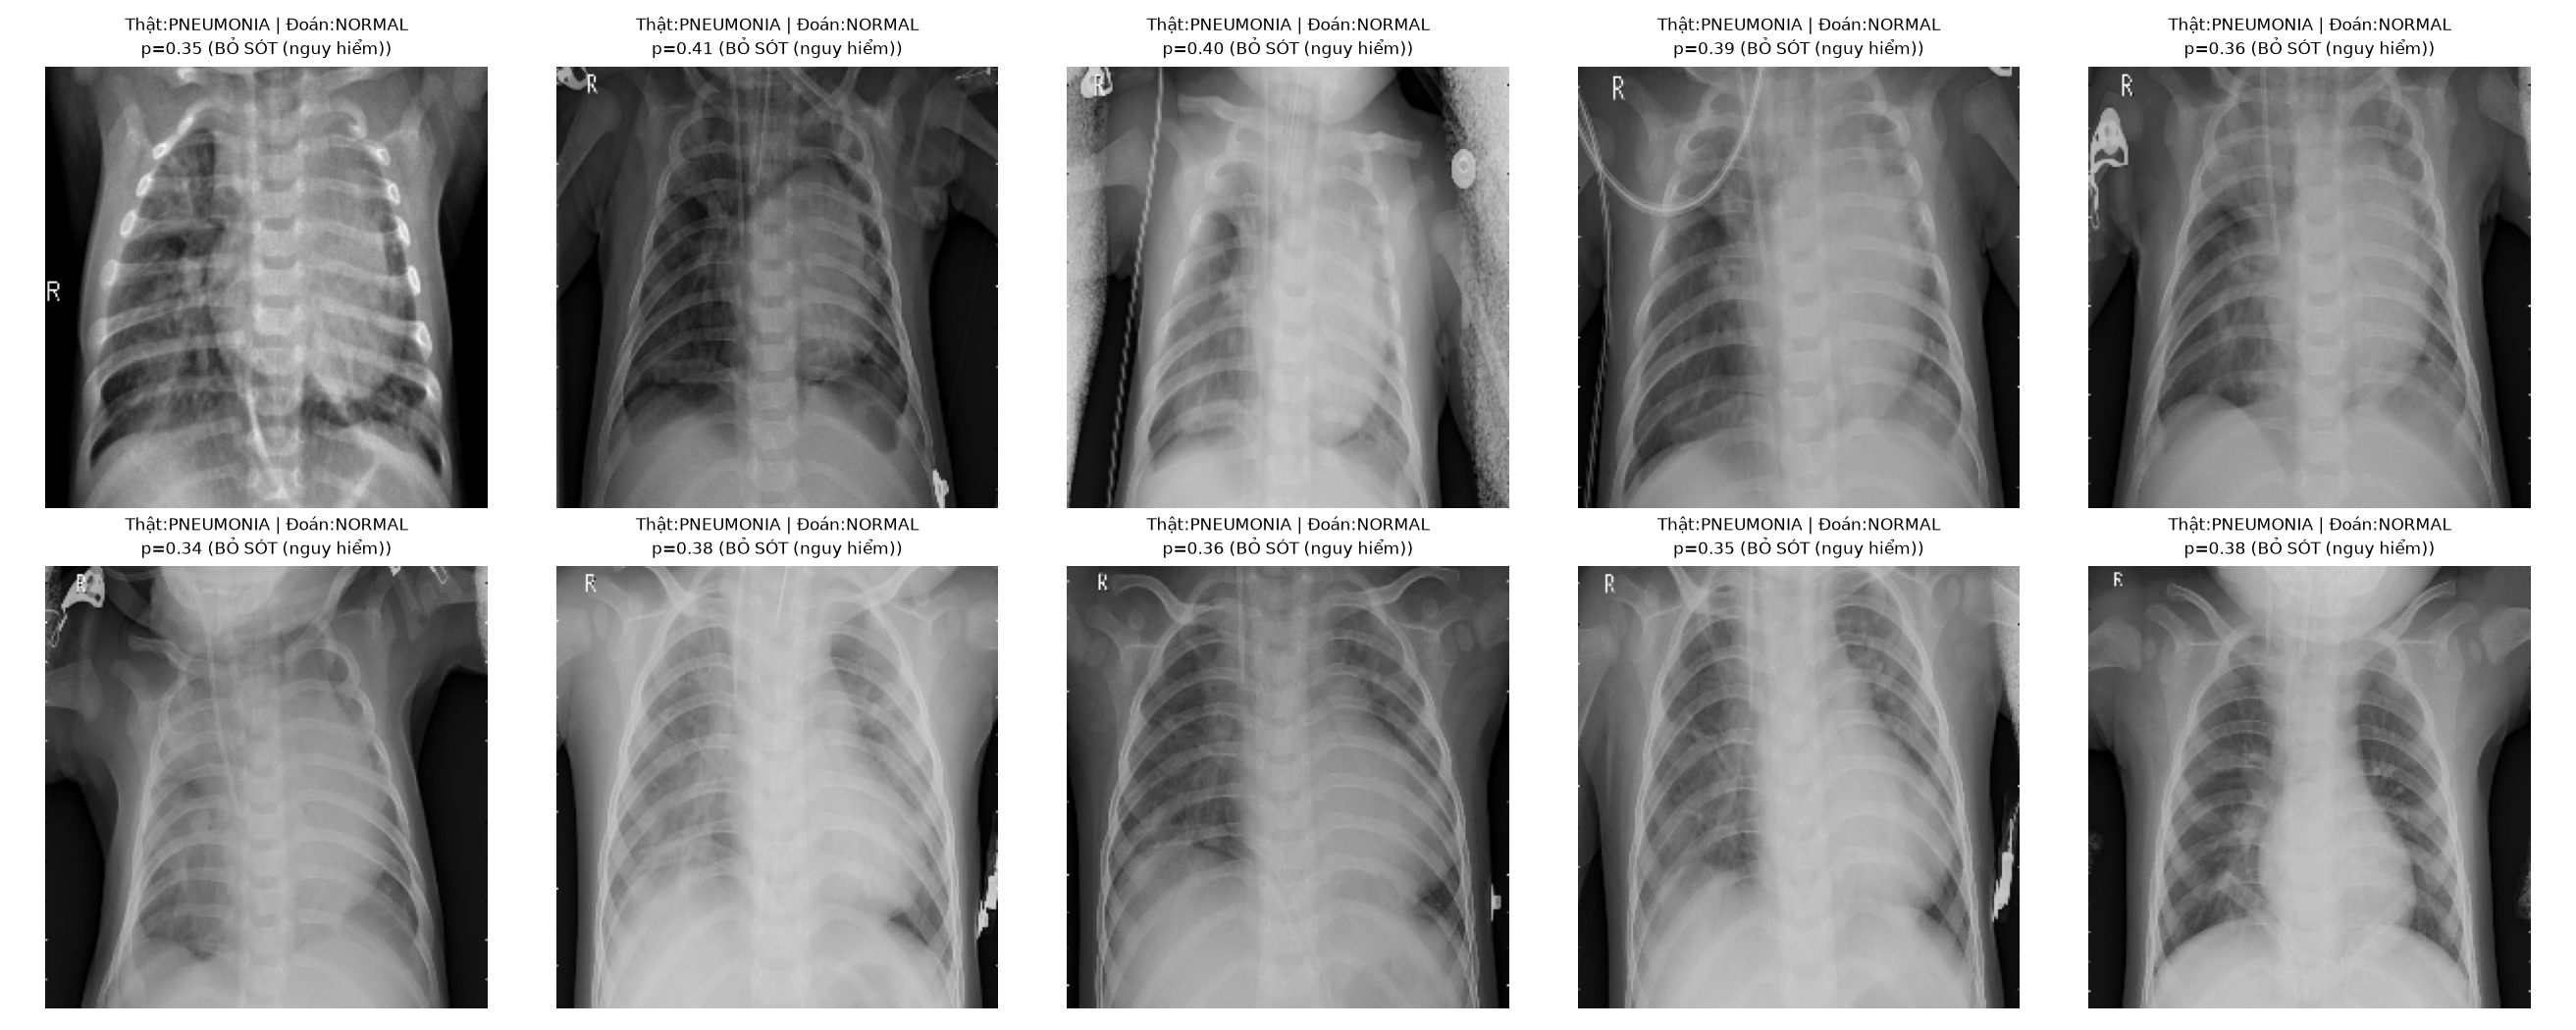

In [20]:
from IPython.display import Image, display
for name in ["learning_curves.png", "confusion_matrix_test.png", "gradcam_examples.png", "ca_du_doan_sai.png"]:
    p = f"reports/{name}"
    if os.path.exists(p):
        print(name); display(Image(p))